In [3]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
   전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

<font size="6" color="red">ch11. 데이터프레임과 시리즈(Pandas)_1절~8절</font>
- pip install pandas (아나콘다 프롬포트) -> 아나콘다를 설치하지 않았을때 사용

# 1절. 판다스 패키지
- 데이터 분석을 위해 반드시 알아야할 패키지. 넘파이를 기반으로 하며, 다른 많은 라이브러리와 잘 통합되도록 설계
- 1차원 구조를 갖는 시리즈 / 2차원 구조를 갖는 데이터 프레임을 제공
- 판다스 장점 : 데이터 프레임 생성, 파일 i/o, 레이블링, 부분데이터추출, 크기변경(행이나 열삽입 삭제),
                       데이터 분할, 병합, 데이터 정렬, 결측치 처리, 피벗과 언피벗 등이 용이
- API 레퍼런스 사이트 - https://pandas.pydata.org/docs/reference/index.html

In [1]:
import pandas as pd
pd.__version__

'1.5.3'

In [2]:
data = pd.read_json('data/ch09_member1.json',
                                    # encoding='utf-8' 판다스 read 함수의 기본 encoding은 utf-8
                                    )
display(data)
print(type(data))

,name,age,email,address
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


<class 'pandas.core.frame.DataFrame'>


In [3]:
member4 = pd.read_csv('data/ch09_member4.csv') # 해더가 있는 csv
member4

,name,age,email,address
0,홍길동,20,kildong@hong.com,서울시 관악구
1,김길동,40,kimdong@hong.com,서울시 영등포구
2,신길동,30,sindong@hong.com,서울시 동작구


In [4]:
pd.read_hdf('data/ch09_iris.h5', key="iris")

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


# 2절. 데이터 프레임 만들기
## 2.1 딕셔너리를 이용해서 데이터 프레임 만들기

In [5]:
d = {'kor':[100,90], 'mat':[95,99]}
df = pd.DataFrame(data=d)
df

,kor,mat
0,100,95
1,90,99


In [6]:
df.to_dict() # 데이터프레임을 딕셔너리로

{'kor': {0: 100, 1: 90}, 'mat': {0: 95, 1: 99}}

In [7]:
df.to_numpy() # 데이터프레임을 넘파이배열

array([[100,  95],
       [ 90,  99]], dtype=int64)

In [8]:
d = [{'kor':100, 'mat':95.0}, 
     {'kor':90, 'mat':99}]
df = pd.DataFrame(d) #데이터 프레임의 열은 동일 자료형
df

,kor,mat
0,100,95.0
1,90,99.0


In [9]:
df.dtypes # 데이터 프레임의 열별 타입

kor      int64
mat    float64
dtype: object

In [10]:
df.info() # ★ 많이 사용 ★

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kor     2 non-null      int64  
 1   mat     2 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 160.0 bytes


In [11]:
import numpy as np
df['kor'] = df['kor'].astype(np.float64) # 데이터프레임의 열 타입 변경
df

,kor,mat
0,100.0,95.0
1,90.0,99.0


In [12]:
d = [{'kor': 100, 'mat':100},
        {'kor':90, 'mat':99},
        {'kor':83, 'eng':85}]
df = pd.DataFrame(data=d)
df

,kor,mat,eng
0,100,100.0,NaN
1,90,99.0,NaN
2,83,NaN,85.0


In [13]:
type(np.nan) # 결측치의 타입 : float

float

In [14]:
# 결측치는 int로 형변환 불가

## 2.2 리스트를 이용해서 데이터프레임 만들기

In [15]:
kor = [100, 90, 80, 70, 60]
mat = [90, 80, 81, 71, 61]
df = pd.DataFrame({'kor' : kor, 'mat':mat})
df

,kor,mat
0,100,90
1,90,80
2,80,81
3,70,71
4,60,61


In [16]:
pd.DataFrame(np.c_[kor, mat], columns=['kor', 'mat'])

,kor,mat
0,100,90
1,90,80
2,80,81
3,70,71
4,60,61


In [17]:
l = [[100, 90], [70, 80]]
pd.DataFrame(l, columns=['국어', '수학'])

,국어,수학
0,100,90
1,70,80


- data.go.kr에서 "상가상권 정보" 다운로드 / "민간 아파트 분양가격" 다운로드

In [18]:
%ls C:\ai\downloads\sharedata\상가정보

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: A014-DCD6

 C:\ai\downloads\sharedata\상가정보 디렉터리

2026-07-14  오후 05:39    <DIR>          .
2026-07-14  오후 05:40    <DIR>          ..
2026-07-14  오후 05:39             1,011 [필독]파일열람방법.txt
2026-07-14  오후 05:39        61,321,696 소상공인시장진흥공단_상가(상권)정보_강원_202603.csv
2026-07-14  오후 05:39       367,852,181 소상공인시장진흥공단_상가(상권)정보_경기_202603.csv
2026-07-14  오후 05:39        92,474,293 소상공인시장진흥공단_상가(상권)정보_경남_202603.csv
2026-07-14  오후 05:39        76,309,810 소상공인시장진흥공단_상가(상권)정보_경북_202603.csv
2026-07-14  오후 05:39        40,031,721 소상공인시장진흥공단_상가(상권)정보_광주_202603.csv
2026-07-14  오후 05:39        61,825,564 소상공인시장진흥공단_상가(상권)정보_대구_202603.csv
2026-07-14  오후 05:39        41,866,930 소상공인시장진흥공단_상가(상권)정보_대전_202603.csv
2026-07-14  오후 05:39        84,329,596 소상공인시장진흥공단_상가(상권)정보_부산_202603.csv
2026-07-14  오후 05:39       292,646,735 소상공인시장진흥공단_상가(상권)정보_서울_202603.csv
2026-07-14  오후 05:39         9,651,297 소상공인시장진흥공단_상가(상권)정보_세종_202603.csv
2026-07-14  오후 05:39        28,285,232 소상공인시장진흥공단

In [19]:
df = pd.read_csv(r'C:\ai\downloads\sharedata\상가정보\소상공인시장진흥공단_상가(상권)정보_세종_202603.csv',
                             # encoding = 'utf-8', sep=',',
                             nrows=30,    # 처음 30행만 가져오기
                             low_memory=False, # 데이터 용량이 클 경우 기입
                             )
df.shape # 30행 39열

(30, 39)

In [20]:
df.head(1)

,상가업소번호,상호명,지점명,상권업종대분류코드,상권업종대분류명,상권업종중분류코드,상권업종중분류명,상권업종소분류코드,상권업종소분류명,표준산업분류코드,...,건물관리번호,건물명,도로명주소,구우편번호,신우편번호,동정보,층정보,호정보,경도,위도
0,MA010120220813963449,레인카페,NaN,I2,음식,I212,비알코올,I21201,카페,I56229,...,4473025021101010001038753,NaN,세종특별자치시 세종특별자치시 조치원읍 조치원8길 16,339883.0,30027,NaN,지,NaN,127.300453,36.600906


In [21]:
# 판다스 디스플레이스 옵션
pd.options.display.max_columns = 39 # 39열까지 display
pd.options.display.max_rows = 40 # 30행까지 display

In [22]:
df.head(2).T

,0,1
상가업소번호,MA010120220813963449,MA010120220805872513
상호명,레인카페,수와마을
지점명,NaN,NaN
상권업종대분류코드,I2,I2
상권업종대분류명,음식,음식
상권업종중분류코드,I212,I201
상권업종중분류명,비알코올,한식
상권업종소분류코드,I21201,I20101
상권업종소분류명,카페,백반/한정식
표준산업분류코드,I56229,I56111


## 2.3 read_csv

In [23]:
# (1) CSV 파일 불러오기(기본값)
import pandas as pd
member = pd.read_csv('data/ch11_member.csv')
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,#홍길뜽,24,non@not.com,없는구,2000-01-01


In [24]:
member.info() # ★

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Name     6 non-null      object
 1   Age      6 non-null      int64 
 2   Email    6 non-null      object
 3   Address  6 non-null      object
 4   Birth    6 non-null      object
dtypes: int64(1), object(4)
memory usage: 368.0+ bytes


<img src="출력결과_구조설명.png" width="700" align="left">

In [25]:
# 문자형으로 변환
member['Age'] = member['Age'].astype('str')
member.dtypes

Name       object
Age        object
Email      object
Address    object
Birth      object
dtype: object

In [26]:
# 숫자형으로 변환
member['Age'] # 보기

0    20
1    30
2    21
3    22
4    23
5    24
Name: Age, dtype: object

In [27]:
import numpy as np
member['Age'] = member['Age'].astype('float32')
member['Age'] = member['Age'].astype(np.float32)
member['Age'] = pd.to_numeric(member['Age'],
                              downcast='integer', # 빼면 int32나 float64로 자동 변환
                              errors='coerce')     # 숫자로 바꿀 수 없는 데이터는 결측치로 변환 ex) 3,000
member.dtypes

Name       object
Age          int8
Email      object
Address    object
Birth      object
dtype: object

In [28]:
# 문자로 읽어들인 Birth를 datetime형으로
# 1999-01-01, 01-01-1999, 19990101
member['Birth'] = member['Birth'].astype('datetime64[ns]') # 1999-01-01
member.astype({'Birth' : 'datetime64[ns]','Age':'int32'})
# 01-01-1999, 19990101
member['Birth'] = pd.to_datetime(member['Birth'],
                           # format='%y=%m=%d %H:%M:%S'
                            )
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     6 non-null      object        
 1   Age      6 non-null      int8          
 2   Email    6 non-null      object        
 3   Address  6 non-null      object        
 4   Birth    6 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int8(1), object(3)
memory usage: 326.0+ bytes


In [29]:
member['year'] = member.Birth.dt.year
member['month'] = member.Birth.dt.month
member['day'] = member.Birth.dt.day
member

,Name,Age,Email,Address,Birth,year,month,day
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30
5,#홍길뜽,24,non@not.com,없는구,2000-01-01,2000,1,1


In [30]:
current_date = pd.to_datetime('2026-07-15')
member['일수'] = (current_date - member.Birth).dt.days
member

,Name,Age,Email,Address,Birth,year,month,day,일수
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,1999,1,1,10057
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,1999,12,1,9723
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,1999,11,1,9753
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,1999,5,1,9937
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,1999,1,30,10028
5,#홍길뜽,24,non@not.com,없는구,2000-01-01,2000,1,1,9692


In [31]:
# (2) 특정 행을 제외하고 cp949 encoding 파일 읽어오기
member = pd.read_csv('data/ch11_membercp949.csv',
                                         encoding='cp949', # cp949의 장점은 엑셀에서 열림
                                         skiprows=[1, 6]) # 1행, 6행 제외하고 읽기
member # 1행, 6행 제외하고 읽기

,Name,Age,Email,Address,Birth
0,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
1,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
2,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
3,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [32]:
# (3) sep='|', 주석(#)제외, 상위 몇행만, datetime형 필드지정
member_df = pd.read_csv('data/ch11_membersep.csv',
                                                sep='|',                                    # | 기준으로 데이터를 분리해서 읽기
                                                   comment='#',                      # #이 있는 행은 제외하고 읽기
                                                       nrows=3,                          # 상위 3행만 읽기
                                                           parse_dates=['Birth']) # datetime 형으로 읽어올 필드 지정
member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [33]:
member_df = pd.read_csv('data/ch11_membertab.csv',
                                                sep='\t',
                                                   comment='#',
                                                       parse_dates=['Birth'])
member_df

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 2.4 패키지에서 가져오기 : iris데이터
- iris가져오기 방법1 : sklearn(머신러닝 패키지)
- iris가져오기 방법2 : statsmodels (R 데이터)
- iris가져오기 방법3 : seaborn(시각화 패키지)

### 2.4.1 iris방법1 : sklearn
- sklearn.datasets 모듈 데이터(iris)를 데이터프레임으로 변환

In [34]:
from sklearn import datasets
# import sklearn.datasets as datasets : 머신러닝을 공부하기 위한 학습용 데이터셋을 제공
# sklearn 패키지의 데이터셋 : 독립변수(입력변수)와 종속변수(타겟변수)가 분리된 딕셔너리 형태 제공
iris = datasets.load_iris() # 딕셔너리형태
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [35]:
print(iris.DESCR) # iris 데이터셋에 대한 설명

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [36]:
iris.data # 독립변수
iris['data'][:3]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2]])

In [37]:
iris.feature_names # 독립변수의 열이름
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [38]:
# 데이터프레임에서 독립변수 열 이름
[col[:-5].replace(' ', '_') for col in iris.feature_names]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [39]:
[col[:12].strip().replace(' ', '_') for col in iris.feature_names]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

In [40]:
# 종속변수(타겟변수)
iris.target
iris['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [41]:
iris.target_names
iris['target_names']

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [42]:
# 데이터프레임에 추가할 가장 오른쪽 열(타겟변수-species)
iris.target_names[iris.target]
iris['target_names'][iris['target']]

array(['setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'setosa', 'setosa', 'setosa', 'setosa',
       'setosa', 'setosa', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolor', 'versicolor', 'versicolor', 'versicolor',
       'versicolo

In [43]:
# 독립변수 : [col[:-5].replace(' ', '_') for col in iris.feature_names]
data = iris.data
print(data[::50])
# 종속변수 : species
target = iris.target_names[iris.target].reshape(-1, 1)
print(target[::50])

[[5.1 3.5 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.3 3.3 6.  2.5]]
[['setosa']
 ['versicolor']
 ['virginica']]


In [44]:
print('독립변수의 차원 :', data.shape)
print('종속변수의 차원 :', target.shape)

독립변수의 차원 : (150, 4)
종속변수의 차원 : (150, 1)


In [45]:
# 방법 1) 독립변수, 종속변수를 stack한 후, 데이터프레임으로 생성
import numpy as np
df = pd.DataFrame(np.hstack( (data, target) ),
                                columns=[col[:-5].replace(' ', '_') for col in iris.feature_names] + ['specise'])
df.head(3) # 상위 5행만

,sepal_length,sepal_width,petal_length,petal_width,specise
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [46]:
df['petal_width']
df.petal_width[:3]

0    0.2
1    0.2
2    0.2
Name: petal_width, dtype: object

In [47]:
df = pd.DataFrame(np.hstack( (data, target) ),
                                columns=iris.feature_names + ['specise'])
df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),specise
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


In [48]:
df['petal width (cm)'][:3]
# df.petal width (cm)

0    0.2
1    0.2
2    0.2
Name: petal width (cm), dtype: object

In [49]:
# 방법 2) 독립변수, 종속변수를 따로 데이터프로임으로 생성한 후 두 데이터프레임을 연결
# X : 독립변수 데이터프레임
X = pd.DataFrame(data, columns=[col[:-5].replace(' ', '_') for col in iris.feature_names])
X.head(1)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2


In [50]:
# y : 종속변수 데이터프레임
y = pd.DataFrame(target, columns=['species'])
y.tail() # 하위 출력 기본값은 5줄

,species
145,virginica
146,virginica
147,virginica
148,virginica
149,virginica


In [51]:
print(X.index) # index:행이름
print(y.index)

RangeIndex(start=0, stop=150, step=1)
RangeIndex(start=0, stop=150, step=1)


In [52]:
# 두 데이터 프레임을 연결(열로 연결)
iris_df = pd.concat( [X, y] , axis=1 )
iris_df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [53]:
iris_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


### 2.4.2 iris방법2: statsmodels

In [136]:
from statsmodels.api import datasets
iris_dataset = datasets.get_rdataset('iris',
                                                                package='datasets',
                                                                    cache=True) # 데이터를 pc에 저장 (~/statsmodels)
iris_dataset

<class 'statsmodels.datasets.utils.Dataset'>

In [55]:
iris = iris_dataset.data
iris.head()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [56]:
iris['Sepal.Length']
# iris.Sepal.Length 불가능 .이나 기호때문에 인식을 잘못함

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: Sepal.Length, Length: 150, dtype: float64

In [57]:
# 열이름 수정 / 이름.replace('수정할것').lower()
[col.replace('.','_').lower() for col in iris.columns]

['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [58]:
iris.columns = [col.replace('.','_').lower() for col in iris.columns]
iris.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

### 2.4.3 iris방법3 : seaborn

In [59]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [60]:
# 데이터프레임을 파일로 출력
iris.to_csv('data/ch11_iris.csv', # 4.01 KB
                   # sep=',',
                     # encoding='urf-8',
                        index=False) # 행이름이 생략되어 파일 출력

In [61]:
iris.to_csv('data/ch11_iris.gz', # 885B
                       index=False,
                           compression='infer') # 파일 확장자(.zip, .gz, .bz2등)를 보고 자동으로 압축형식을 추론해서 압축

In [62]:
load_iris = pd.read_csv('data/ch11_iris.csv')
load_iris.sample(3) # 임의로 (개수) 가져오기

,sepal_length,sepal_width,petal_length,petal_width,species
44,5.1,3.8,1.9,0.4,setosa
126,6.2,2.8,4.8,1.8,virginica
131,7.9,3.8,6.4,2.0,virginica


In [63]:
load_iris = pd.read_csv('data/ch11_iris.gz', compression='infer')
load_iris.sample(3)

,sepal_length,sepal_width,petal_length,petal_width,species
29,4.7,3.2,1.6,0.2,setosa
81,5.5,2.4,3.7,1.0,versicolor
111,6.4,2.7,5.3,1.9,virginica


# 3절. 이름(열,행) 지정하기
## 3.1 열 이름 지정하기

In [64]:
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [65]:
member.columns # 열이름

Index(['Name', 'Age', 'Email', 'Address', 'Birth'], dtype='object')

In [66]:
# step 1) 열 이름 바꾸기
member.columns = ['이름', '나이', '이메일', '주소', '생년월일']
member

,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.2 행이름 지정

In [67]:
member.index # 행이름

RangeIndex(start=0, stop=5, step=1)

In [68]:
member.index = range(10,15)
member

,이름,나이,이메일,주소,생년월일
10,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
11,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
12,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
13,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
14,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [69]:
member.index = ['동','서','남','북','중']
member

,이름,나이,이메일,주소,생년월일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [70]:
member['이름']['서'] # 해당 방법은 잘 안씀

'홍길서'

In [71]:
member.loc['서','이름'] # 주로 사용 -> loc[행이름, 열이름]으로 부분 데이터 조회(4절 참고)

'홍길서'

In [72]:
member

,이름,나이,이메일,주소,생년월일
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [73]:
print(member.index)
print(member.index.name)

Index(['동', '서', '남', '북', '중'], dtype='object')
None


In [74]:
# 이름을 행이름으로 -> 실행결과가 출력되서 나오면 return될뿐, member가 안 바뀜.
# member의 이름열을 행이름으로 수정 -> (1) 할당  (2) inplace매개변수에 True(기본값은 False)
member.set_index('이름', inplace=True)

In [75]:
member

,나이,이메일,주소,생년월일
이름,,,,
홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
홍길서,30,seo@hong.com,서울시 중구,1999-12-01
홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [76]:
print(member.index)
print(member.index.name)
print(member.columns)

Index(['홍길동', '홍길서', '홍길남', '홍길북', '홍길중'], dtype='object', name='이름')
이름
Index(['나이', '이메일', '주소', '생년월일'], dtype='object')


In [77]:
# 인덱스를 열에 편입시키기
# member.reset_index(inplace=True)
member = member.reset_index()

In [78]:
member.index = [0,4,1,2,3]
member

,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
4,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
1,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
2,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
3,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [79]:
# 기존 index를 0부터 새롭게 다시 numbering <- 비추천
member.index = range(len(member)) # 비추천
member

,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [80]:
member.index = [99,77,88,66,33]
# 기존 index를 새로운 열에 편입시키지 않고 제거 후 숫자 index를 초기화 (추천)
member.reset_index(drop=True, inplace=True) # inplace=True는 해당 변수를 해당 입력값으로 재설정
member

,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 3.3 레벨이름 지정하기

In [81]:
print(member.columns)
print(member.columns.name)
display(member)

Index(['이름', '나이', '이메일', '주소', '생년월일'], dtype='object')
None


,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [82]:
member.columns.name = '컬럼명'
member

컬럼명,이름,나이,이메일,주소,생년월일
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [83]:
member.columns = [['기본정보','기본정보','기본정보','추가정보','추가정보'],
                                        ['이름', '나이', '메일', '주소', '생년월일']]
member.columns.names = ['대분류','소분류']
member

대분류 기본정보                        추가정보           
소분류   이름  나이             메일       주소       생년월일
0    홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
1    홍길서  30   seo@hong.com   서울시 중구 1999-12-01
2    홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
3    홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
4    홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [84]:
member.index = [['좌우','좌우','상하','상하','상하'],
                                    ['동', '서', '남', '북', '중']]
member.index.names = ['레벨1', '레벨2']
member

대분류     기본정보                        추가정보           
소분류       이름  나이             메일       주소       생년월일
레벨1 레벨2                                            
좌우  동    홍길동  20  hong@hong.com  서울시 강동구 1999-01-01
    서    홍길서  30   seo@hong.com   서울시 중구 1999-12-01
상하  남    홍길남  21   nam@hong.com  서울시 강동구 1999-11-01
    북    홍길북  22   buk@hong.com  서울시 관악구 1999-05-01
    중    홍길중  23   mid@hong.com   부산시 중구 1999-01-30

In [85]:
member[('기본정보', '이름')]

레벨1  레벨2
좌우   동      홍길동
     서      홍길서
상하   남      홍길남
     북      홍길북
     중      홍길중
Name: (기본정보, 이름), dtype: object

In [86]:
member.loc['상하']

대분류 기본정보                       추가정보           
소분류   이름  나이            메일       주소       생년월일
레벨2                                           
남    홍길남  21  nam@hong.com  서울시 강동구 1999-11-01
북    홍길북  22  buk@hong.com  서울시 관악구 1999-05-01
중    홍길중  23  mid@hong.com   부산시 중구 1999-01-30

In [87]:
member.loc[('상하','남'), ('기본정보','이름')]

'홍길남'

In [88]:
member.xs(key='남', level='레벨2')

대분류 기본정보                       추가정보           
소분류   이름  나이            메일       주소       생년월일
레벨1                                           
상하   홍길남  21  nam@hong.com  서울시 강동구 1999-11-01

In [89]:
member.loc['좌우','기본정보']

소분류,이름,나이,메일
레벨2,,,
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com


# 4절. 부분 데이터 조회

In [90]:
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 4.1 열 조회
- df [열이름]
- df [조건]
- df [열이름들]

In [91]:
member['Name']
member.Name

0    홍길동
1    홍길서
2    홍길남
3    홍길북
4    홍길중
Name: Name, dtype: object

In [92]:
member[ ['Name', 'Age','Birth']]

,Name,Age,Birth
0,홍길동,20,1999-01-01
1,홍길서,30,1999-12-01
2,홍길남,21,1999-11-01
3,홍길북,22,1999-05-01
4,홍길중,23,1999-01-30


In [93]:
member[ ['Name', 'Age', 'Birth'] ]

,Name,Age,Birth
0,홍길동,20,1999-01-01
1,홍길서,30,1999-12-01
2,홍길남,21,1999-11-01
3,홍길북,22,1999-05-01
4,홍길중,23,1999-01-30


In [94]:
# member[0] : 행이름으로 조회할 경우 loc 사용

## 4.2 loc을 이용한 조회
- df.loc[행이름, 열이름] : 행이름과 열이름으로 조회
    * 행이름과 열이름 자리에 슬라이싱(from:to)은 from부터 to까지 (to포함)
    * 행이름과 열이름 자리에 list가능
    * 열이름 생략할 경우 모든 열 조회

In [95]:
member.loc[0:2] # 0행부터 2행까지
member.loc[0:2, ]
member.loc[0:2, :]
member.loc[0:2, ...]
# 모든 열을 다 출력할 경우 생략가능

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [96]:
member.index = ['동', '서', '남', '북', '중']
member.loc['동':'남']

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [97]:
# 동~남행까지 Name~Email
member.loc['동':'남', 'Name':'Email']

,Name,Age,Email
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com
남,홍길남,21,nam@hong.com


In [99]:
# 동행과 남행만 조회
member.loc[['동','남']]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [100]:
# 동행과 남행의 Name과 Email만 조회
member.loc[['동','남'], ['Name','Email']]

,Name,Email
동,홍길동,hong@hong.com
남,홍길남,nam@hong.com


In [101]:
# 모든 행의 Name열
member.loc[:,'Name'] # 한열이나 한행은 결과가 1차원 시리즈
member.loc[...,'Name']

동    홍길동
서    홍길서
남    홍길남
북    홍길북
중    홍길중
Name: Name, dtype: object

In [102]:
member.loc['동']

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 동, dtype: object

In [103]:
type(member.loc['동']), type(member.loc[:, 'Name'])

(pandas.core.series.Series, pandas.core.series.Series)

## 4.3 iloc을 이용한 조회
- df.iloc[행번호, 열번호]
    * 행번호, 열번호 자리에는 list, 슬라이싱 [from:stop:by] : from부터 stop앞까지 by씩
    * 열번호 생략시 모든 열 조회

In [104]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [105]:
# 2번째~3번째 행 (0이 처음)
member.loc['남':'북']
member.iloc[2:4]

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [106]:
member.iloc[0] # 1차원 시리즈

Name                       홍길동
Age                         20
Email            hong@hong.com
Address                서울시 강동구
Birth      1999-01-01 00:00:00
Name: 동, dtype: object

In [107]:
# 0번째 ~ 2번째행, 1번째~2번째열
member.iloc[0:3, 1:3]

,Age,Email
동,20,hong@hong.com
서,30,seo@hong.com
남,21,nam@hong.com


In [108]:
# 0번째행과2번째행, 1번째열과 3번째열
member.iloc[ [0,2], [1,3] ]

,Age,Address
동,20,서울시 강동구
남,21,서울시 강동구


In [110]:
# 짝수번째행(0,2,4번째)의 맨 마지막열을 제회하고 조회
member.iloc[::2, :-1]

,Name,Age,Email,Address
동,홍길동,20,hong@hong.com,서울시 강동구
남,홍길남,21,nam@hong.com,서울시 강동구
중,홍길중,23,mid@hong.com,부산시 중구


In [111]:
# 마지막행부터 처음행까지 꺼꾸로 출력
member.iloc[::-1]

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


## 4.4 조건으로 조회

In [112]:
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [113]:
member['Age']>=23

동    False
서     True
남    False
북    False
중     True
Name: Age, dtype: bool

In [114]:
member.loc[[False, True, False, False, True]]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [115]:
# 23세 이상의 데이터만 조회 (아래 모두 동일한 결과)
member.loc[member['Age']>=23]
member.loc[member['Age']>=23, :]
member[member['Age']>=23]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [116]:
# 23세 이상의 데이터 중 Name, Age, Email
member.loc[member['Age']>=23, 'Name':'Email']

,Name,Age,Email
서,홍길서,30,seo@hong.com
중,홍길중,23,mid@hong.com


In [117]:
# 23세 이상의 데이터 중 Name, Email
member.loc[member['Age']>=23, ['Name','Email'] ]

,Name,Email
서,홍길서,seo@hong.com
중,홍길중,mid@hong.com


In [118]:
# 23세 이상이 아닌 데이터(모든 열) : ~ (반대)
member[~(member['Age']>=23)]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01


In [119]:
# 관악구가 포함되어 있는지
address = '서울시 관악구 신림동'
print(address.find('관악구')!=-1)
print(address.find('중구')!=-1)
# 서울시로 시작되는지 
print(address.startswith('서울시'))

True
False
True


In [120]:
# member['Address'].find('중구') # 시리즈에 문자함수를 바로 사용X

In [121]:
member['Address'].str.find('중구')!=-1

동    False
서     True
남    False
북    False
중     True
Name: Address, dtype: bool

In [122]:
# Address에 중구가 포함된 데이터
member[member['Address'].str.find('중구')!=-1]
member.loc[member['Address'].str.find('중구')!=-1]
member.loc[member['Address'].str.find('중구')!=-1, :]

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [123]:
# Address에 중구가 포함된 데이터의 Name, Age, Email
member.loc[member['Address'].str.find('중구')!=-1, 'Name':'Email']
member.loc[member['Address'].str.find('중구')!=-1, ['Name','Age','Email'] ]

,Name,Age,Email
서,홍길서,30,seo@hong.com
중,홍길중,23,mid@hong.com


In [137]:
# Address가 중구 or 관악구가 포함된 데이터
member[member['Address'].str.contains('중구|관악구')]

,Name,Age,Email,Address,Birth
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [124]:
# Address가 서울이 아닌 데이터
member[~member['Address'].str.startswith('서울')]

,Name,Age,Email,Address,Birth
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [125]:
# Name이 홍길동이거나 홍길남이거나 홍길서인 데이터의 모든 열
member[(member['Name']=='홍길동') | (member['Name']=='홍길남') | (member['Name']=='홍길서')]
member[member['Name'].isin(['홍길동','홍길남','홍길서'])]

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01


In [126]:
# Name이 홍길동이거나 홍길남이거나 홍길서인 데이터의 Name, Age, Email
member.loc[member['Name'].isin(['홍길동','홍길남','홍길서']), 'Name':'Email']
member.loc[member['Name'].isin(['홍길동','홍길남','홍길서']), ['Name','Age','Email']]

,Name,Age,Email
동,홍길동,20,hong@hong.com
서,홍길서,30,seo@hong.com
남,홍길남,21,nam@hong.com


In [127]:
# 1월생인 데이터
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member[member['Birth'].dt.month==1]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [128]:
# 1월생이면서 서울시인 데이터
member[(member.Birth.dt.month==1) & member.Address.str.startswith('서울시')]

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [129]:
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [130]:
import numpy as np
member.loc[[2,4], 'Email'] = np.nan
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,NaN,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


In [131]:
member.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Name     5 non-null      object        
 1   Age      5 non-null      int64         
 2   Email    3 non-null      object        
 3   Address  5 non-null      object        
 4   Birth    5 non-null      datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 328.0+ bytes


In [132]:
member.isna() # 모든 행과 열에 결측치 여부

,Name,Age,Email,Address,Birth
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,True,False,False
3,False,False,False,False,False
4,False,False,True,False,False


In [133]:
False + False + False

0

In [134]:
True + True + False

2

In [135]:
# 각 열의 결측치 갯수
member.isna().sum()

Name       0
Age        0
Email      2
Address    0
Birth      0
dtype: int64

In [138]:
# Email이 결측치인 행
member[member['Email'].isna()]

,Name,Age,Email,Address,Birth
2,홍길남,21,NaN,서울시 강동구,1999-11-01
4,홍길중,23,NaN,부산시 중구,1999-01-30


※ 데이터 프레임의 부분 데이터 조회 방법
- df[열이름] : 특정 열(들)의 모든 행 조회
- df[조건]    : 조건에 맞는 행의 모든 열 조회
- df.loc[행이름 혹은 조건, 열이름] : 행이름(조건)과 열이름으로 조회
    * 행이름 자리에 조건 가능
    * 행이름, 열이름 자리에 list, 슬라이싱
    * 열이름 생략시 모든 열
- df.iloc[행번호, 열번호] : 번호로 조회
    * 행번호, 열번호 자리에 list, 슬라이싱
    * 열번호 생략시 모든 열

# 연습문제

In [262]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()
iris.iloc[::50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [263]:
# 1. sepal_length 열만 출력
iris['sepal_length']
iris.sepal_length

0      5.1
1      4.9
2      4.7
3      4.6
4      5.0
      ... 
145    6.7
146    6.3
147    6.5
148    6.2
149    5.9
Name: sepal_length, Length: 150, dtype: float64

In [264]:
# 2. 0~10행까지 마지막 열을 제외한 데이터 (loc, iloc)
iris.loc[0:10]
iris.iloc[0:11]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [265]:
# 3. 3~10 행중에 'sepal_length'와 'petal_length' 열만 (loc, iloc)
iris.loc[3:10, 'sepal_length':'petal_length']
iris.iloc[3:11, 0:3]

,sepal_length,sepal_width,petal_length
3,4.6,3.1,1.5
4,5.0,3.6,1.4
5,5.4,3.9,1.7
6,4.6,3.4,1.4
7,5.0,3.4,1.5
8,4.4,2.9,1.4
9,4.9,3.1,1.5
10,5.4,3.7,1.5


In [266]:
# 4. 0번째, 50번째, 100번째 행의 모든 열 (loc, iloc)
iris.loc[::50,]
iris.iloc[::50,]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
50,7.0,3.2,4.7,1.4,versicolor
100,6.3,3.3,6.0,2.5,virginica


In [267]:
# 5. 0번째, 25, 50번째, 75번, 100번째, 125번째 행의 petal_length와 petal_width (loc, iloc)
iris.loc[::25, 'petal_length':'petal_width']
iris.iloc[::25, 2:4]

,petal_length,petal_width
0,1.4,0.2
25,1.6,0.2
50,4.7,1.4
75,4.4,1.4
100,6.0,2.5
125,6.0,1.8


In [277]:
# 6. species가 versicolor인 데이터의 모든 열
iris[iris.species=='versicolor']
iris[iris['species']=='versicolor']

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
51,6.4,3.2,4.5,1.5,versicolor
52,6.9,3.1,4.9,1.5,versicolor
53,5.5,2.3,4.0,1.3,versicolor
54,6.5,2.8,4.6,1.5,versicolor
...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,versicolor
96,5.7,2.9,4.2,1.3,versicolor
97,6.2,2.9,4.3,1.3,versicolor
98,5.1,2.5,3.0,1.1,versicolor


In [269]:
# 7. species가 setosa인 데이터 최초 5개 행만 출력
iris[iris['species']=='setosa'].head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [240]:
# 8. sepal_length가 6.5이상인 데이터 최초 5개 행만 출력
iris[iris['sepal_length']>6.5].head()

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor


In [233]:
# 9. sepal_length가 7.2이상인 데이터의 'sepal_length'와 'sepal_width'와 'petal_length'
iris.loc[iris['sepal_length']>7.2, ['sepal_length', 'sepal_width', 'petal_length']]

,sepal_length,sepal_width,petal_length
105,7.6,3.0,6.6
107,7.3,2.9,6.3
117,7.7,3.8,6.7
118,7.7,2.6,6.9
122,7.7,2.8,6.7
130,7.4,2.8,6.1
131,7.9,3.8,6.4
135,7.7,3.0,6.1


In [244]:
# 10. versicolor종중에서 sepal_length가 6.5보다 큰 데이터의 모든 열
iris[(iris.species=='versicolor') & (iris.sepal_length>6.5)]

,sepal_length,sepal_width,petal_length,petal_width,species
50,7.0,3.2,4.7,1.4,versicolor
52,6.9,3.1,4.9,1.5,versicolor
58,6.6,2.9,4.6,1.3,versicolor
65,6.7,3.1,4.4,1.4,versicolor
75,6.6,3.0,4.4,1.4,versicolor
76,6.8,2.8,4.8,1.4,versicolor
77,6.7,3.0,5.0,1.7,versicolor
86,6.7,3.1,4.7,1.5,versicolor


# 5절. 데이터 삭제 및 추가
## 5.1 데이터 프레임의 요소 삭제
- df.drop(열이름이나 행이름, axis ) : axis=0일때는 행삭제, axis=1일때는 열삭제

In [54]:
import pandas as pd
member = pd.read_csv('data/ch11_member.csv', comment='#')
member.index = ['동','서','남','북','중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [55]:
# 1) 단일 행 삭제
member.drop('동') # axis=0(기본값)이면 행이름을 찾아 삭제한 결과를 반환
                               # 삭제한 결과를 member에 적용  방법1) 할당 / 방법2) inplace=True 매개변수 추가

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [56]:
member = member.drop('동')

In [57]:
# 2) 복수행 삭제
member.drop(['서','남']) # <- axis=0 기본값으로 생략됨.

,Name,Age,Email,Address,Birth
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [58]:
# 3) 열 삭제
member.drop(['Age', 'Birth'], axis=1, inplace=True)

In [59]:
member

,Name,Email,Address
서,홍길서,seo@hong.com,서울시 중구
남,홍길남,nam@hong.com,서울시 강동구
북,홍길북,buk@hong.com,서울시 관악구
중,홍길중,mid@hong.com,부산시 중구


## 5.2 데이터프레임의 요소 추가
※ 열추가

In [60]:
member = pd.read_csv('data/ch11_member.csv', comment='#', parse_dates=['Birth'])
member['no'] = 7
member

,Name,Age,Email,Address,Birth,no
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7


In [61]:
new_col = pd.Series([7,8,9], index=[0,1,4]) # index에 지정된 행을 내용으로 추가함.
new_col

0    7
1    8
4    9
dtype: int64

In [62]:
member['출생년도'] = member['Birth'].dt.year
member

,Name,Age,Email,Address,Birth,no,출생년도
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01,7,1999
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01,7,1999
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01,7,1999
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01,7,1999
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30,7,1999


※ 행추가

In [63]:
member = pd.read_csv('data/ch11_member.csv', comment='#')
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [70]:
new_member = pd.DataFrame([
                            {
                                'Name':'홍길숙',
                                'Age':'29',
                                'Email':'suk@hong.com',
                                'Address':'서울시',
                                'Birth':'2000-01-01'
                             },{
                                'Name':'홍길숙',
                                'Age':'29',
                                'Email':'suk@hong.com',
                                'Address':'서울시',
                                'Birth':'2000-01-01'
                            }])
new_member

,Name,Age,Email,Address,Birth
0,홍길숙,29,suk@hong.com,서울시,2000-01-01
1,홍길숙,29,suk@hong.com,서울시,2000-01-01


In [72]:
# 데이터프레임 연결
member = pd.concat( [member, new_member], axis=0 ) # axis=0 기본값

In [74]:
member.reset_index(drop=True, inplace=True)

In [75]:
member

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,suk@hong.com,서울시,2000-01-01
6,홍길숙,29,suk@hong.com,서울시,2000-01-01


In [76]:
new_series = pd.Series(['이상함', -20, 'l@l.com', '이상한나라', '1000-01-01'],
                                          index=member.columns)
pd.DataFrame(new_series).T

,Name,Age,Email,Address,Birth
0,이상함,-20,l@l.com,이상한나라,1000-01-01


In [77]:
pd.concat([member, pd.DataFrame(new_series).T]).reset_index(drop=True)

,Name,Age,Email,Address,Birth
0,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
1,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
2,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
3,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
4,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
5,홍길숙,29,suk@hong.com,서울시,2000-01-01
6,홍길숙,29,suk@hong.com,서울시,2000-01-01
7,이상함,-20,l@l.com,이상한나라,1000-01-01


# 6절. 병합과 연결
## 6.1 merge()를 이용한 데이터 프레임 병합

In [88]:
df1 = pd.DataFrame({'key'  : ['a','b','c','d'],
                                    'c1'   : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key'  : ['a','b','c','f'],
                                    'c2'   : [5, 6, 7, 8]})
display(df1)
display(df2)

,key,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key,c2
0,a,5
1,b,6
2,c,7
3,f,8


In [89]:
df1.merge(df2) # how = 'inner' : 내부조인(양쪽 다 일치하는 데이터만 병합)

,key,c1,c2
0,a,1,5
1,b,2,6
2,c,3,7


In [90]:
df1.merge(df2, how='left') # 왼쪽 데이터는 모두 남기고 오른쪽 df2를 병합

,key,c1,c2
0,a,1,5.0
1,b,2,6.0
2,c,3,7.0
3,d,4,NaN


In [91]:
df1.merge(df2, how='right') # 오른쪽 데이터는 모두 남기고 왼쪽 df1을 병합

,key,c1,c2
0,a,1.0,5
1,b,2.0,6
2,c,3.0,7
3,f,NaN,8


In [92]:
df1.merge(df2, how='outer') # 양쪽 데이터 모두 다  남김

,key,c1,c2
0,a,1.0,5.0
1,b,2.0,6.0
2,c,3.0,7.0
3,d,4.0,NaN
4,f,NaN,8.0


In [98]:
df1 = pd.DataFrame({'key1'  : ['a','b','c','d'],
                                    'c1'   : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key2'  : ['a','b','c','f'],
                                    'c2'   : [5, 6, 7, 8]})
display(df1)
display(df2)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
1,b,6
2,c,7
3,f,8


In [100]:
df1.merge(df2, left_on='key1', right_on='key2', how='left') # how = 'inner' 기본값
df1.merge(df2, left_on='key1', right_on='key2', how='right')
df1.merge(df2, left_on='key1', right_on='key2', how='outer')

,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,b,6.0
2,c,3.0,c,7.0
3,d,4.0,NaN,NaN
4,NaN,NaN,f,8.0


## 6.2 concat()을 이용한 데이터프레임 연결
- pd.concat([df1, df2], axis)
    * axis=0(기본값) : 위아래로 연결
    * axis=1 : 좌우로 연결

In [103]:
df1 = pd.DataFrame({'key1'  : ['a','b','c','d'],
                                    'c1'   : [1, 2, 3, 4]})
df2 = pd.DataFrame({'key2'  : ['a','b','c','f'],
                                    'c2'   : [5, 6, 7, 8]})
display(df1)
df2.index = [0,2,3,4] # axis = 1 : concat시 행이름 기준으로 연결
display(df2)
pd.concat([df1, df2], axis=1)

,key1,c1
0,a,1
1,b,2
2,c,3
3,d,4


,key2,c2
0,a,5
2,b,6
3,c,7
4,f,8


,key1,c1,key2,c2
0,a,1.0,a,5.0
1,b,2.0,NaN,NaN
2,c,3.0,b,6.0
3,d,4.0,c,7.0
4,NaN,NaN,f,8.0


# 7절. 정렬(행이름, 열이름, 값에 의한 정렬)
- df.sort_index(axis) : 행 또는 열이름으로 정렬
- df.sort_values(by=정렬기준이 될 열이름(복수형도 가능. 리스트로 묶어서), ascending=T/F)  : 값에 의한 정렬

In [104]:
member = pd.read_csv('data/ch11_member.csv', comment='#')
member.index = ['동', '서', '남', '북', '중']
member

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 7.1 행이름으로 정렬

In [117]:
member.sort_index(inplace=True) # axis=0 기본값 # ascending=False 내림차순

In [118]:
member

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


## 7.2 열이름으로 정렬

In [120]:
member.sort_index(axis=1)
member.sort_index(axis='columns', ascending=False) # ascending=False 내림차순 (기본값은 오름차순)

,Name,Email,Birth,Age,Address
남,홍길남,nam@hong.com,1999-11-01,21,서울시 강동구
동,홍길동,hong@hong.com,1999-01-01,20,서울시 강동구
북,홍길북,buk@hong.com,1999-05-01,22,서울시 관악구
서,홍길서,seo@hong.com,1999-12-01,30,서울시 중구
중,홍길중,mid@hong.com,1999-01-30,23,부산시 중구


## 7.3 값에 의한 정렬

In [121]:
member.sort_values(by='Age') # Age열 기준으로 오름차순 정렬

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01


In [122]:
member.sort_values(by='Age', ascending=False)

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [124]:
member.sort_values(by='Name') # Name 기준 오름차순 정렬

,Name,Age,Email,Address,Birth
남,홍길남,21,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,22,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,23,mid@hong.com,부산시 중구,1999-01-30


In [126]:
member.loc[:, 'Age'] = [20,20,20,30,30]
member

,Name,Age,Email,Address,Birth
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30


In [128]:
# Age기준 내림차순 정렬, Age가 같으면 Birth 기준 내림차순
member.sort_values(by=['Age', 'Birth'], ascending=False)

,Name,Age,Email,Address,Birth
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01


In [132]:
# Age기준 내림차순 정렬, Age가 같으면 Birth 기준 오름차순
member.sort_values(by=['Age', 'Birth','Name'], ascending=[True, True, False])

,Name,Age,Email,Address,Birth
동,홍길동,20,hong@hong.com,서울시 강동구,1999-01-01
북,홍길북,20,buk@hong.com,서울시 관악구,1999-05-01
남,홍길남,20,nam@hong.com,서울시 강동구,1999-11-01
중,홍길중,30,mid@hong.com,부산시 중구,1999-01-30
서,홍길서,30,seo@hong.com,서울시 중구,1999-12-01


# 8절. 기초 통계 분석
    * 판다스는 기초 통계. 난이도 있는 통계는 statsmodels에 있음
- count : NaN을 제외한 개수
- min : 최소값
- max : 최대값
- sum : 열별 합
- cumsum : 누적합
- cumprod : 누적곱
    * mean부터
- mean : 평균
- median : 중위수
- 중위수 : 주어진 데이터를 크기 순서대로 나열했을 때 가장 중앙에 위치하는 값
- 결측치 : 데이터 수집 과정에서 측정되지 않거나 누락되어 값이 비어 있는 데이터
- var : 분산
- std : 표준편차
    * std까지 숫자일때만 사용
- quantile : 분위수(0사분위수, Q1:1사분위수, 2사분위수(중위수), Q3:3사분위수, 4사분위수) : 이상치 구하는 용도
    * IQR = Q3 - Q1
    * Q1-1.5*IQR ~ Q3+1.5*IQR 이외의 데이터는 이상치 
- describe : 요약통계량
- corr : -1   <- 상관계수(공분산 나누기 각 변수 별 표준편차) <- 1
- rolling(n).mean() : 데이터에 변동(노이즈)이 많을 때, 추세(패턴)을 부드럽게 보고 싶을 때

In [137]:
member.isna().sum()
member.isnull().sum()

Name       0
Age        0
Email      0
Address    0
Birth      0
dtype: int64

In [158]:
from statsmodels.api import datasets
iris = datasets.get_rdataset('iris').data
iris.columns = [column.replace('.','_').lower() for column in iris.columns]
iris.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


## 8.1 min, max, mean, ...

In [144]:
iris.count() # 열별 데이터 개수(Nan을 제외)

sepal.length    150
sepal.width     150
petal.length    150
petal.width     150
species         150
dtype: int64

In [145]:
iris.min(0) # 열별 최소값(문자필드는 코드값이 작은 것)

sepal.length       4.3
sepal.width        2.0
petal.length       1.0
petal.width        0.1
species         setosa
dtype: object

In [153]:
iris.max()

sepal.length          7.9
sepal.width           4.4
petal.length          6.9
petal.width           2.5
species         virginica
dtype: object

In [148]:
iris.median(axis=0, numeric_only=True) # numeric_only=None 기본값 / =True는 숫자필드만 median 적용

sepal.length    5.80
sepal.width     3.00
petal.length    4.35
petal.width     1.30
dtype: float64

In [160]:
# iris에서 문자필드를 제외한 값을 x
X = iris.loc[:,'sepal_length':'petal_width' ]
X = iris.iloc[:, :-1]
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [165]:
X.mean()      # 열별 평균 == 행들의 평균
X.mean(axis=0)
X.mean(axis='index')
X.mean(axis='rows')

sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64

In [175]:
X.mean(axis=1) # 행별평균 == 행고정하고 열들의 평균
X.mean(axis='columns')[:2] # 1차원이라 ().loc[:]을 한다면 loc 안넣어도 됨

0    2.550
1    2.375
dtype: float64

In [176]:
X.var() # 열별 분산

sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64

In [177]:
X.std() # 열별 표준편차

sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64

In [189]:
data = [1,3,4,7,10]
df = pd.DataFrame(data, columns=['value'])
df['value'].quantile(q=[0, 0.25, 0.5, 0.75, 1], interpolation='linear') 
# midpoint : 중간값으로 계산
# nearest : 가장 가까운 실제값
# linear : 실제값을 선형보간법에 따라 계산된 값을 추출해라.

0.00     1.0
0.25     3.0
0.50     4.0
0.75     7.0
1.00    10.0
Name: value, dtype: float64

In [204]:
qunt = X.quantile(q=[0, 0.25, 0.5, 0.75, 1], ) # 기본값은 interpolation='linear'
qunt
# 각 열별 최소값, Q1, Q2, Q3, 최대값 -> 각 열별 IQR -> 각 열별 이상치 유무

,sepal_length,sepal_width,petal_length,petal_width
0.00,4.3,2.0,1.00,0.1
0.25,5.1,2.8,1.60,0.3
0.50,5.8,3.0,4.35,1.3
0.75,6.4,3.3,5.10,1.8
1.00,7.9,4.4,6.90,2.5


In [223]:
for idx, col in enumerate(qunt.columns):
    min_ =  qunt.iloc[0, idx]
    Q1   =  qunt.iloc[1, idx]
    Q3   =  qunt.iloc[3, idx]
    max_ = qunt.iloc[4, idx]
    iqr   =  Q3 - Q1
    lower_outlier  = Q1 - 1.5*iqr
    upper_outlier = Q3 + 1.5*iqr
    print(f"{col} : {lower_outlier:.2f} ~ {upper_outlier:.2f}까지 정상 범위")
    print(f"lower이상치 여부 : {min_<lower_outlier}, upper이상치 여부 : {max_>upper_outlier}\n")

sepal_length : 3.15 ~ 8.35까지 정상 범위
lower이상치 여부 : False, upper이상치 여부 : False

sepal_width : 2.05 ~ 4.05까지 정상 범위
lower이상치 여부 : True, upper이상치 여부 : True

petal_length : -3.65 ~ 10.35까지 정상 범위
lower이상치 여부 : False, upper이상치 여부 : False

petal_width : -1.95 ~ 4.05까지 정상 범위
lower이상치 여부 : False, upper이상치 여부 : False



In [227]:
# sepal_width의 값이 2.05보다 작거나, 4.05보다 큰 행을 출력하는데, sepal_width기준으로 오름차순 정렬 출력
iris[(iris.sepal_width<2.05) | (iris.sepal_width>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


In [230]:
import numpy as np
iris[np.logical_or(iris.sepal_width<2.05, iris.sepal_width>4.05)].sort_values(by='sepal_width')

,sepal_length,sepal_width,petal_length,petal_width,species
60,5.0,2.0,3.5,1.0,versicolor
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
15,5.7,4.4,1.5,0.4,setosa


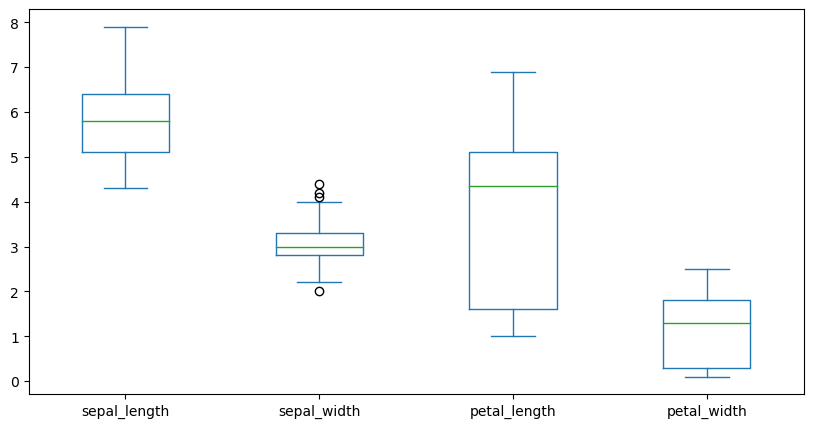

In [231]:
import matplotlib.pyplot as plt
X.plot(kind='box', figsize=(10, 5))
plt.show()

In [237]:
X.rolling(5).mean().iloc[4:10] # 추세를 부드럽게 보고 싶을 때

,sepal_length,sepal_width,petal_length,petal_width
4,4.86,3.28,1.40,0.20
5,4.92,3.36,1.46,0.24
6,4.86,3.44,1.46,0.26
7,4.92,3.48,1.50,0.26
8,4.88,3.44,1.48,0.26
9,4.86,3.34,1.50,0.24


In [236]:
X.iloc[:10]

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


## 8.2 요약통계량

In [238]:
# 1) 기본 요약 통계량
iris.describe() # 기본값 -> 숫자컬럼에서의 요약 통계량

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [245]:
iris['species'].describe()
iris.species.describe() # 문자열에서의 요약 통계량 : 데이터 개수, 종류(unique), 최빈값(top), 최빈값 데이터 개수(freq)

count        150
unique         3
top       setosa
freq          50
Name: species, dtype: object

In [247]:
# 2) describe()의 include와 exclude 매개변수
df = pd.DataFrame({'a' : [1,2,3]*2,
                   'b' : [1.1, 2]*3,
                   'c' : ['aaa','bbb','aaa','ccc','aaa','bbb'],
                   'd' : [True, False]*3})
display(df)
df.info()

,a,b,c,d
0,1,1.1,aaa,True
1,2,2.0,bbb,False
2,3,1.1,aaa,True
3,1,2.0,ccc,False
4,2,1.1,aaa,True
5,3,2.0,bbb,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   a       6 non-null      int64  
 1   b       6 non-null      float64
 2   c       6 non-null      object 
 3   d       6 non-null      bool   
dtypes: bool(1), float64(1), int64(1), object(1)
memory usage: 278.0+ bytes


In [248]:
df.describe(include='all') # df의 모든 열의 요약 통계량 출력

,a,b,c,d
count,6.000000,6.00000,6,6
unique,NaN,NaN,3,2
top,NaN,NaN,aaa,True
freq,NaN,NaN,3,3
mean,2.000000,1.55000,NaN,NaN
std,0.894427,0.49295,NaN,NaN
min,1.000000,1.10000,NaN,NaN
25%,1.250000,1.10000,NaN,NaN
50%,2.000000,1.55000,NaN,NaN
75%,2.750000,2.00000,NaN,NaN


In [250]:
df['c'].unique() # 특정 컬럼의 고유 값들

array(['aaa', 'bbb', 'ccc'], dtype=object)

In [251]:
df['c'].value_counts() # 고유값들의 빈도(내림차순 정렬)

aaa    3
bbb    2
ccc    1
Name: c, dtype: int64

In [252]:
df.select_dtypes(include=object) # 해당 타입의 컬럼만 추출

,c
0,aaa
1,bbb
2,aaa
3,ccc
4,aaa
5,bbb


In [253]:
df.select_dtypes(exclude=object) # 해당 타입의 컬럼만 제외하고 추출

,a,b,d
0,1,1.1,True
1,2,2.0,False
2,3,1.1,True
3,1,2.0,False
4,2,1.1,True
5,3,2.0,False


## 8.3 공분산, 상관계수

- 공분산 : (x1-x1 평균)*(x2-x2평균)들의 합을 n-1을 나눈 값
- 공분산(Covariance) : 두 개의 확률 변수가 함께 변하는 경향을 측정하는 통계적 지표
- 상관 계수(Correlation Coefficient) : 두 변수 간의 통계적 관계를 나타내는 수치
- 모수(parameter) : 전체 모집단의 특성을 요약하거나 설명하는 숫자 (통계학 기준)

In [256]:
X.cov()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


In [263]:
# -1<= 상관계수(공분산/x1의 표준편차*x2의 표준편차) <= 1
X.corr()

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


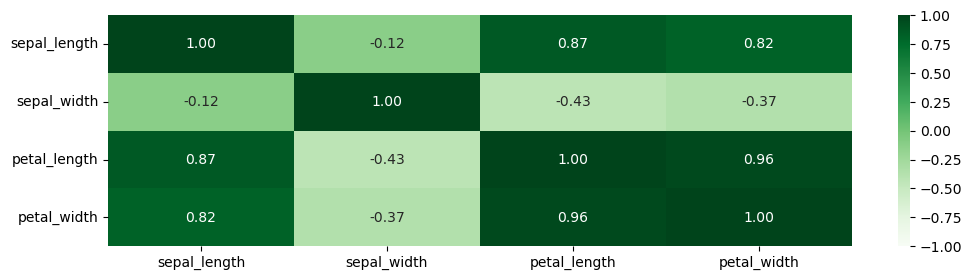

In [269]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,3)) # 그래프 사이즈 조정
sns.heatmap(X.corr(), annot=True, vmin=-1, vmax=1, cmap='Greens', fmt='.2f')
plt.show()